# Ce travail est fait par HADARBACH MED REDA

<h2 style="color:red; font-family:Courier;">
Installez ces packages s'ils ne sont pas presents
</h2>
!pip install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn


# 1. Préparation des données

### 1.1. Importation des bibliothèques nécessaires

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 1.2. Chargement des données

In [ ]:
data = pd.read_csv('creditcard.csv')

# Afficher les premières lignes et un résumé des informations
print("Aperçu des données :")
print(data.head(5))
print("\nInformations sur les colonnes :")
data.info()

Aperçu des données :
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26

### 1.3. Analyse du déséquilibre des classes

In [ ]:
# Nbr d'occurrences pour chaque classe
class_counts = data['Class'].value_counts()
print("\nDistribution des classes :")
print(class_counts)

# Pourcentage de fraude (classe 1)
fraud_percentage = (class_counts[1] / data.shape[0]) * 100
print(f"\nPourcentage de transactions frauduleuses : {fraud_percentage:.3f} %")


Distribution des classes :
Class
0    284315
1       492
Name: count, dtype: int64

Pourcentage de transactions frauduleuses : 0.173 %


Le résultat est < à 1%, le jeu de données est déséquilibré donc il faut gérer l'imbalance

### 1.4. Prétraitement: Scaling & Division

In [ ]:
# Scaling
# Séparer les features (X) de la cible (y)
X = data.drop('Class', axis=1)
y = data['Class']
scaler = StandardScaler()

# Appliquer le scaling sur les colonnes 'Time' et 'Amount'
X['Time'] = scaler.fit_transform(X[['Time']])
X['Amount'] = scaler.fit_transform(X[['Amount']])
print("\nAperçu des données après Scaling :")
print(X.head())

# Division
# Séparer en jeux d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y 
)

print(f"\nForme des données d'entraînement (X_train) : {X_train.shape}")
print(f"Forme des données de test (X_test) : {X_test.shape}")


Aperçu des données après Scaling :
       Time        V1        V2        V3        V4        V5        V6  \
0 -1.996583 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1 -1.996583  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2 -1.996562 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3 -1.996562 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4 -1.996541 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0  0.239599  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474   
1 -0.078803  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288   
2  0.791461  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412   
3  0.237609  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321   
4  0.592941 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458   

        V24       V25       V26 

## 2. Apprentissage des modèles

### 2.1. Gestion d'imbalance (SMOTE)

SMOTE (Synthetic Minority Over-sampling Technique), une méthode populaire qui crée des échantillons synthétiques de la classe minoritaire (fraude) pour équilibrer le jeu d'entraînement.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Distribution des classes d'entraînement avant SMOTE : {Counter(y_train)}")
print(f"Distribution des classes d'entraînement après SMOTE : {Counter(y_train_resampled)}")

Distribution des classes d'entraînement avant SMOTE : Counter({0: 199020, 1: 344})
Distribution des classes d'entraînement après SMOTE : Counter({0: 199020, 1: 199020})


### 2.2. Entraînement des Trois Méthodes

### 2.2.1. K-Nearest Neighbors (k-nn)

On choisit une valeur initiale pour k. (k=5)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

#Initialisation
k = 5
knn_model = KNeighborsClassifier(n_neighbors=k)

#Entraînement
print(f"Démarrage de l'entraînement k-NN (k={k})")
knn_model.fit(X_train_resampled, y_train_resampled)
print("Entraînement k-NN terminé")

#Prédictions sur X_test original
y_pred_knn = knn_model.predict(X_test)

Démarrage de l'entraînement k-NN (k=5)
Entraînement k-NN terminé


### 2.2.2. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

#Entraînement
print("Démarrage de l'entraînement Random Forest")
rf_model.fit(X_train_resampled, y_train_resampled)
print("Entraînement Random Forest terminé")

#Prédictions sur X_test original
y_pred_rf = rf_model.predict(X_test)

Démarrage de l'entraînement Random Forest
Entraînement Random Forest terminé


### 2.2.3. SVM

On a utilisé LinearSVC pour plus de rapidité sur ce type de données

In [ ]:
from sklearn.svm import LinearSVC

#Initialisation (dual=False est recommandé lorsque n_samples > n_features)
svm_model = LinearSVC(random_state=42, dual=False, max_iter=10000)

#Entraînement
print("Démarrage de l'entraînement LinearSVC")
#capturer l'erreur Max Iteration si elle survient
try:
    svm_model.fit(X_train_resampled, y_train_resampled)
    print("Entraînement LinearSVC terminé")
except Exception as e:
    print(f"Erreur d'entraînement LinearSVC : {e}")
    
#Prédictions sur X_test original
y_pred_svm = svm_model.predict(X_test)

Démarrage de l'entraînement LinearSVC
Entraînement LinearSVC terminé


## 3. Évaluation des performances

### 3.1. Importer Outils

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

### 3.2. Fonction d'Evaluation Globale

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    """Calcule, affiche et retourne les métriques d'évaluation pour un modèle."""
    print(f"Résultats pour {model_name}")
    
    #Matrice de Confusion
    cm = confusion_matrix(y_true, y_pred)
    
    #Affichage graphique
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraude (0)", "Fraude (1)"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matrice de Confusion : {model_name}")
    plt.show()
    
    # TN (True Negative) = cm[0, 0]
    # FP (False Positive) = cm[0, 1]
    # FN (False Negative) = cm[1, 0] <- la fraude manquée!
    # TP (True Positive) = cm[1, 1]

    #Calcul des Métriques
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Taux de Classification (Accuracy) : {accuracy:.4f}")
    print(f"Rappel (Recall) : {recall:.4f}")
    print(f"Précision (Precision) : {precision:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("-" * 30)

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Recall': recall,
        'Precision': precision,
        'F1-Score': f1
    }

#stocker les résultats
results_list = []

### 3.3. Évaluation pour chaque modèle
On va appeler la fonction en utilisant y_test

### 3.3.1. Modèle K-NN

Résultats pour k-NN


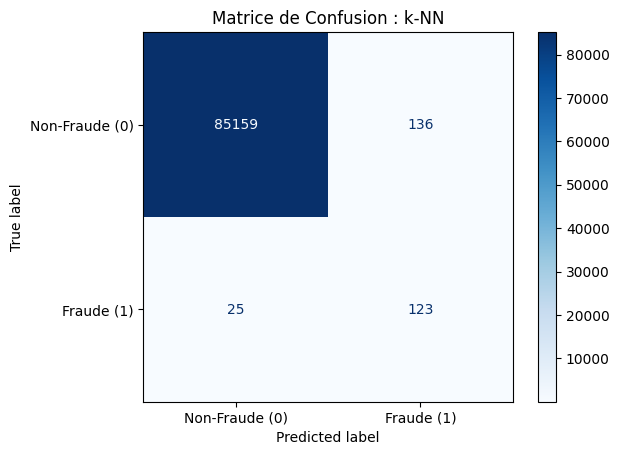

Taux de Classification (Accuracy) : 0.9981
Rappel (Recall) : 0.8311
Précision (Precision) : 0.4749
F1-Score : 0.6044
------------------------------


In [ ]:
knn_metrics = evaluate_model(y_test, y_pred_knn, "k-NN")
results_list.append(knn_metrics)

### 3.3.2. Modèle Random Forest

Résultats pour Random Forest


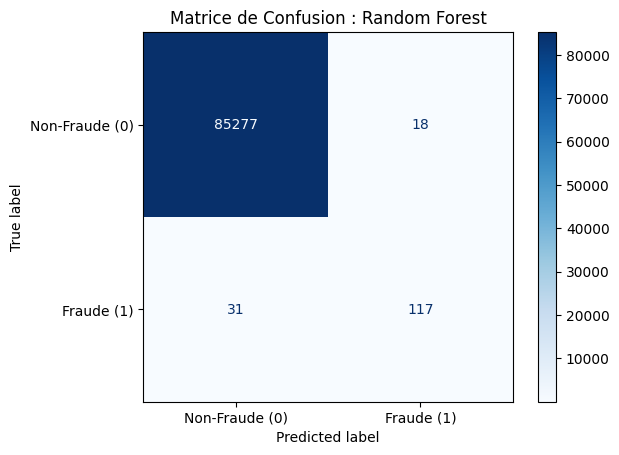

Taux de Classification (Accuracy) : 0.9994
Rappel (Recall) : 0.7905
Précision (Precision) : 0.8667
F1-Score : 0.8269
------------------------------


In [ ]:
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest")
results_list.append(rf_metrics)

### 3.3.3. Modèle SVM

Résultats pour SVM (LinearSVC)


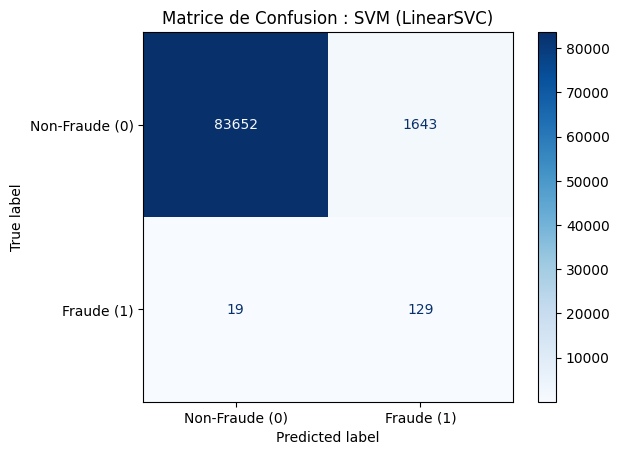

Taux de Classification (Accuracy) : 0.9805
Rappel (Recall) : 0.8716
Précision (Precision) : 0.0728
F1-Score : 0.1344
------------------------------


In [ ]:
svm_metrics = evaluate_model(y_test, y_pred_svm, "SVM (LinearSVC)")
results_list.append(svm_metrics)

### 3.4. Synthèse des Performances
On créé un tableau récapitulatif

In [ ]:
comparaison_df = pd.DataFrame(results_list)

print("\nTableau Récapitulatif des Performances Globales")
print(comparaison_df.set_index('Model').sort_values(by='F1-Score', ascending=False))


Tableau Récapitulatif des Performances Globales
                 Accuracy    Recall  Precision  F1-Score
Model                                                   
Random Forest    0.999427  0.790541   0.866667  0.826855
k-NN             0.998116  0.831081   0.474903  0.604423
SVM (LinearSVC)  0.980548  0.871622   0.072799  0.134375


## 4. Discussion des Résultats

### 4.1. Analyse Critique de l'Accuracy (Taux de Classification)

Accuracy est très élevée (99%) pour tous les modèles.
Mais elle reste une métrique non fiable car elle signifie que le modèle est bon pour identifier la classe majoritaire (Non-Fraude) mais pas la classe minoritaire.

### 4.2. Interprétation de Recall et de Precision

Pour Recall, la capacité à détecter toutes les fraudes réelles est minimiser les Faux Négatifs - FN. Un recall élevé signifie que le modèle manque peu de fraudes.

Pour Precision, la capacité à s'assurer que lorsqu'une transaction est étiquetée "Fraude", elle est vraiment frauduleuse, donc minimiser les Faux Positifs - FP. Une Précision très faible peut signifier que la banque bloque trop de transactions légales.

### 4.3. Utilisation du F1-Score pour le Choix Final

Le F1-Score est la moyenne harmonique du Recall et de Precision. 

Le modèle avec le F1-Score le plus élevé est généralement considéré comme le meilleur pour ce type de problème, car il offre le meilleur compromis entre ne pas manquer la fraude et ne pas générer trop de fausses alertes.

### 4.4. Comparaison des Modèles

- Random Forest : Il excelle souvent grâce à sa nature d'ensemble, sa capacité à gérer la non-linéarité, et sa robustesse. Ses scores de Rappel est inférieur qux autres et pour F1 il est largement supérieur aux autres modèles.

- k-NN : Il est très sensible au (curse of dimensionality) et à la méthode de sampling. L'application de SMOTE a été bénéfique, mais il peut être plus lent à la prédiction que les autres.

- SVM (LinearSVC) : Les scores de la Précision et F1-Score sont inférieurs par rapport aux autres modèles. Le LinearSVC peut avoir du mal à capturer les relations complexes non linéaires par rapport au Random Forest.

### Conclusion

Basé sur l'analyse, le modèle Random Forest obtient la meilleure performance globale avec un F1-Score de 82.6%, suivi par le k-NN. Bien que le SVM ait une Accuracy élevée, son Recall est plus faible, ce qui signifie qu'il manque plus de cas de fraude que les autres.

Dans le contexte de la détection de fraude, le Rappel est essentiel pour minimiser les pertes financières. Par conséquent, le Random Forest est le classifieur le plus adapté pour ce jeu de données rééquilibré